# OT Analysis of Cross-Attention Distributions
**Fairseq DE-EN hallucination corpus** · WMT18

### Setup

In [1]:
import numpy as np
import pandas as pd
import ot
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import mannwhitneyu, spearmanr
from tqdm import tqdm
from typing import Dict, Any

pd.set_option('display.float_format', '{:.4f}'.format)
num_layers = 6


### Load extracted attention data

In [ ]:
# Please, refer to extraction.py for details on how the attention data and labels were generated.
df = pd.read_pickle("./hallucinations-in-nmt/attention_per_layer.pkl")

print(f"Loaded {len(df)} rows")
print(f"Columns: {df.columns.tolist()}")
print(f"\nExample attn shape: {df.iloc[0]['attn'].shape}  (T × layers × src_len)")
print(f"\nLabel counts:")
for col in ['repetitions', 'named-entities', 'omission', 'strong-unsupport', 'full-unsupport']:
    if col in df.columns:
        print(f"  {col}: {int(df[col].sum())} positive")

Loaded 3414 rows
Columns: ['Unnamed: 0', 'src', 'mt', 'ref', 'repetitions', 'named-entities', 'omission', 'strong-unsupport', 'full-unsupport', 'attn', 'attn_aggregated', 'mt_len']

Example attn shape: (9, 6, 12)  (T × layers × src_len)

Label counts:
  repetitions: 87 positive
  named-entities: 41 positive
  omission: 204 positive
  strong-unsupport: 164 positive
  full-unsupport: 129 positive


### OT helpers  

In [3]:
from functools import lru_cache

@lru_cache(maxsize=None)
def build_ground_metric_cached(n: int) -> np.ndarray:
    if n <= 1:
        return np.zeros((n, n), dtype=np.float64)
    idx = np.arange(n, dtype=np.float64)
    return np.abs(idx[:, None] - idx[None, :]) / (n - 1)


def sinkhorn_w1(a: np.ndarray, b: np.ndarray, reg: float = 0.01) -> float:
    """Regularised W1 via Sinkhorn — used for layer-pairwise and step OT."""
    a = np.clip(np.asarray(a, dtype=np.float64), 0, None)
    b = np.clip(np.asarray(b, dtype=np.float64), 0, None)
    if a.sum() == 0 or b.sum() == 0:
        return np.nan
    a = a / a.sum()
    b = b / b.sum()
    M = build_ground_metric_cached(len(a))
    return float(ot.sinkhorn2(a, b, M, reg=reg, numItermax=200, stopThr=1e-6))


def w1_exact_1d(a: np.ndarray, b: np.ndarray) -> float:
    """Exact W1 for 1-D distributions via the CDF difference formula.

    W1(a, b) = integral |F_a(x) - F_b(x)| dx
    Discretised on a shared support of length n, normalised to [0,1].
    O(n), no Sinkhorn approximation.
    """
    n = max(len(a), len(b))
    a = np.pad(np.asarray(a, dtype=np.float64), (0, n - len(a)))
    b = np.pad(np.asarray(b, dtype=np.float64), (0, n - len(b)))
    a = np.clip(a, 0, None); a /= (a.sum() + 1e-9)
    b = np.clip(b, 0, None); b /= (b.sum() + 1e-9)
    return float(np.sum(np.abs(np.cumsum(a) - np.cumsum(b)))) / max(n - 1, 1)


def concentration_to_uniform(a: np.ndarray) -> float:
    """Exact W1 distance from attention vector a to the uniform distribution.

    Uses the positional ground metric (ell_1 on token indices, normalised to
    [0,1]), computed exactly via the CDF formula — no Sinkhorn approximation.
    Higher values indicate more concentrated (less uniform) attention.
    """
    a = np.clip(np.asarray(a, dtype=np.float64), 0, None)
    if a.sum() == 0:
        return np.nan
    u = np.ones(len(a)) / len(a)
    return w1_exact_1d(a, u)


### Compute OT metrics for every sentence

For each sentence with attention array `π` of shape `[T, layers, S]` we compute:
- `concentration_matrix` — shape `[layers, T]`: Wass-to-Uniform per layer per step
- `layer_ot_matrix` — shape `[6, 6]`: pairwise OT between layer-averaged distributions
- `step_ot_matrix` — shape `[layers, T-1]`: consecutive-step OT per layer

In [4]:
def compute_ot_metrics(pi: np.ndarray, reg: float = 0.01) -> Dict[str, Any]:
    """
    pi: [T, num_layers, src_len]  (output of extraction script)
    Returns dict of scalar summaries and matrices.

    Concentration is computed with exact W1 to uniform (w1_exact_1d).
    Layer-pairwise and step-to-step OT use regularised Sinkhorn (sinkhorn_w1).
    """
    pi = np.transpose(pi, (1, 0, 2))
    num_layers, num_steps, src_len = pi.shape

    concentration = np.zeros((num_layers, num_steps), dtype=np.float64)
    for l in range(num_layers):
        for t in range(num_steps):
            concentration[l, t] = concentration_to_uniform(pi[l, t])

    layer_reps = []
    for l in range(num_layers):
        rep = pi[l].mean(axis=0)
        rep = rep / (rep.sum() + 1e-9)
        layer_reps.append(rep)
    layer_reps = np.stack(layer_reps, axis=0)

    layer_ot = np.zeros((num_layers, num_layers), dtype=np.float64)
    for i in range(num_layers):
        for j in range(num_layers):
            layer_ot[i, j] = sinkhorn_w1(layer_reps[i], layer_reps[j], reg=reg)

    step_ot = np.full((num_layers, max(num_steps - 1, 0)), np.nan, dtype=np.float64)
    if num_steps >= 2:
        for l in range(num_layers):
            for t in range(num_steps - 1):
                step_ot[l, t] = sinkhorn_w1(pi[l, t], pi[l, t + 1], reg=reg)

    return {
        "concentration_matrix":           concentration,
        "layer_ot_matrix":                layer_ot,
        "step_ot_matrix":                 step_ot,
        "mean_concentration":             float(np.nanmean(concentration)),
        "std_concentration":              float(np.nanstd(concentration)),
        "mean_layer_ot":                  float(np.nanmean(layer_ot)),
        "mean_step_ot":                   float(np.nanmean(step_ot)) if step_ot.size > 0 else np.nan,
        "final_layer_mean_concentration": float(np.nanmean(concentration[-1])),
        "first_layer_mean_concentration": float(np.nanmean(concentration[0])),
    }


In [ ]:
# Only if you need to recompute the metrics (slow), otherwise load from precomputed file.
metrics_list = []
for _, row in tqdm(df.iterrows(), total=len(df)):
    try:
        m = compute_ot_metrics(row["attn"])
    except Exception as e:
        m = {k: np.nan for k in [
            "mean_concentration", "std_concentration", "mean_layer_ot",
            "mean_step_ot", "final_layer_mean_concentration",
            "first_layer_mean_concentration",
            "concentration_matrix", "layer_ot_matrix", "step_ot_matrix"
        ]}
    metrics_list.append(m)

metrics_df = pd.DataFrame(metrics_list)

scalar_cols = [
    "mean_concentration", "std_concentration", "mean_layer_ot",
    "mean_step_ot", "final_layer_mean_concentration", "first_layer_mean_concentration",
]
for col in scalar_cols:
    df[col] = metrics_df[col].values

df["concentration_matrix"] = metrics_df["concentration_matrix"].values
df["layer_ot_matrix"]      = metrics_df["layer_ot_matrix"].values
df["step_ot_matrix"]       = metrics_df["step_ot_matrix"].values

print("Done.")
df[scalar_cols].describe()

In [ ]:
# Only if you need to recompute the metrics (slow), otherwise load from precomputed file.
df.to_pickle("ot_metrics.pkl")

In [5]:
df = pd.read_pickle("ot_metrics.pkl")

---
## Experiment 1 — Layer-wise Variation
How much do attention distributions change across the 6 decoder layers?

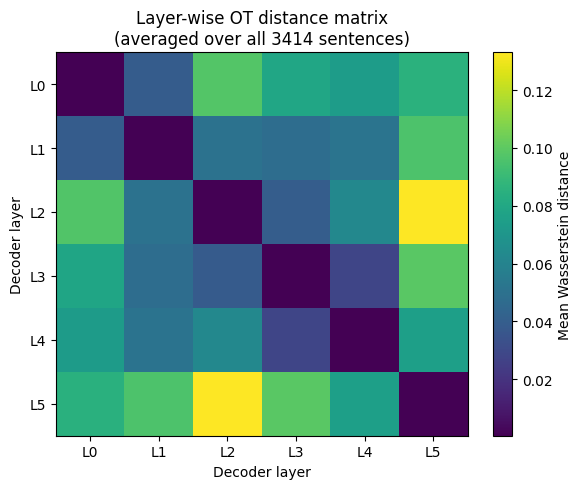

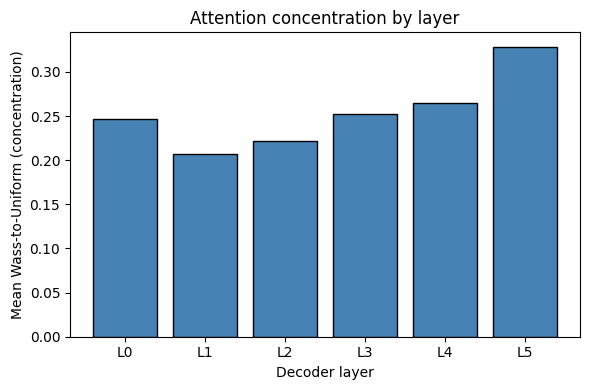

In [6]:
valid_matrices = [m for m in df["layer_ot_matrix"] if isinstance(m, np.ndarray)]
mean_layer_ot = np.nanmean(np.stack(valid_matrices, axis=0), axis=0)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(mean_layer_ot, aspect="auto", cmap="viridis")
plt.colorbar(im, ax=ax, label="Mean Wasserstein distance")
ax.set_title("Layer-wise OT distance matrix\n(averaged over all 3414 sentences)")
ax.set_xlabel("Decoder layer")
ax.set_ylabel("Decoder layer")
ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels([f"L{i}" for i in range(6)])
ax.set_yticklabels([f"L{i}" for i in range(6)])
plt.tight_layout()
plt.show()

valid_conc = [m for m in df["concentration_matrix"] if isinstance(m, np.ndarray)]
mean_conc_per_layer = np.nanmean(
    [m.mean(axis=1) for m in valid_conc], axis=0
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(6), mean_conc_per_layer, color="steelblue", edgecolor="black")
ax.set_xlabel("Decoder layer")
ax.set_ylabel("Mean Wass-to-Uniform (concentration)")
ax.set_title("Attention concentration by layer")
ax.set_xticks(range(6))
ax.set_xticklabels([f"L{i}" for i in range(6)])
plt.tight_layout()
plt.show()

---
## Experiment 2 — Correctness Separation

The corpus has binary labels for three hallucination types. We compare OT signatures between:
- **Hallucinations** (any of: `full-unsupport`, `strong-unsupport`, `repetitions`)
- **Correct** translations (all label columns = 0)

In [9]:
hallucination_cols = ['full-unsupport', 'strong-unsupport', 'repetitions']
all_label_cols     = ['full-unsupport', 'strong-unsupport', 'repetitions',
                      'named-entities', 'omission']
available_label_cols = [c for c in all_label_cols if c in df.columns]

# A sentence is 'correct' only when every annotation column is 0.
# This excludes the 'incorrect' category (errors that are not hallucinations)
# so the negative class matches the paper's definition.
df['is_hallucination'] = df[hallucination_cols].fillna(0).max(axis=1).astype(bool)
is_correct = (df[available_label_cols].fillna(0) == 0).all(axis=1)

# quality_group is defined only for sentences that are either a hallucination
# (by the three primary types) or strictly correct — middle-ground 'incorrect'
# sentences are excluded from group comparisons.
df['quality_group'] = np.where(
    df['is_hallucination'], 'hallucination',
    np.where(is_correct, 'correct', None)
)

print(df['quality_group'].value_counts(dropna=False))
print(f"Excluded (incorrect, non-hallucination): {df['quality_group'].isna().sum()}")


quality_group
correct          2882
hallucination     324
NaN               208
Name: count, dtype: int64
Excluded (incorrect, non-hallucination): 208


In [11]:
scalar_cols = [
    "mean_concentration", "std_concentration", "mean_layer_ot",
    "mean_step_ot", "final_layer_mean_concentration", "first_layer_mean_concentration",
]

def compare_groups(df: pd.DataFrame, column: str, group_col: str = 'quality_group',
                   group_a: str = 'hallucination', group_b: str = 'correct'):
    a = df[df[group_col] == group_a][column].dropna()
    b = df[df[group_col] == group_b][column].dropna()
    stat, p = mannwhitneyu(a, b, alternative="two-sided")
    return {
        "column": column,
        f"{group_a}_mean": float(a.mean()),
        f"{group_b}_mean": float(b.mean()),
        "p_value": float(p),
        "significant": p < 0.05,
    }

results = []
for col in scalar_cols:
    results.append(compare_groups(df, col))

results_df = pd.DataFrame(results).sort_values("p_value")
print(results_df.to_string(index=False))

                        column  hallucination_mean  correct_mean  p_value  significant
                  mean_step_ot              0.0819        0.1242   0.0000         True
             std_concentration              0.0896        0.1040   0.0000         True
            mean_concentration              0.2955        0.2490   0.0000         True
first_layer_mean_concentration              0.2566        0.2460   0.0000         True
                 mean_layer_ot              0.0554        0.0593   0.0000         True
final_layer_mean_concentration              0.3381        0.3284   0.0003         True


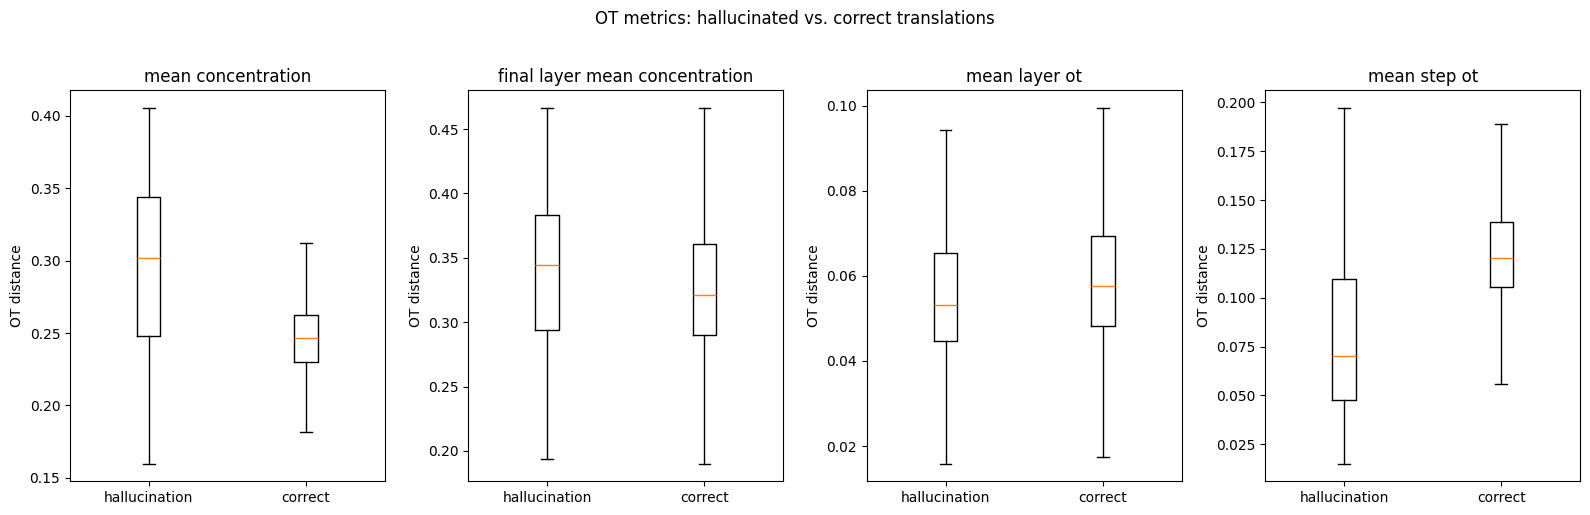

In [12]:
plot_cols = ["mean_concentration", "final_layer_mean_concentration",
             "mean_layer_ot", "mean_step_ot"]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, col in zip(axes, plot_cols):
    groups = [
        df[df['quality_group'] == 'hallucination'][col].dropna().values,
        df[df['quality_group'] == 'correct'][col].dropna().values,
    ]
    ax.boxplot(groups, tick_labels=['hallucination', 'correct'], showfliers=False)
    ax.set_title(col.replace('_', ' '))
    ax.set_ylabel("OT distance")
plt.suptitle("OT metrics: hallucinated vs. correct translations", y=1.02)
plt.tight_layout()
plt.show()

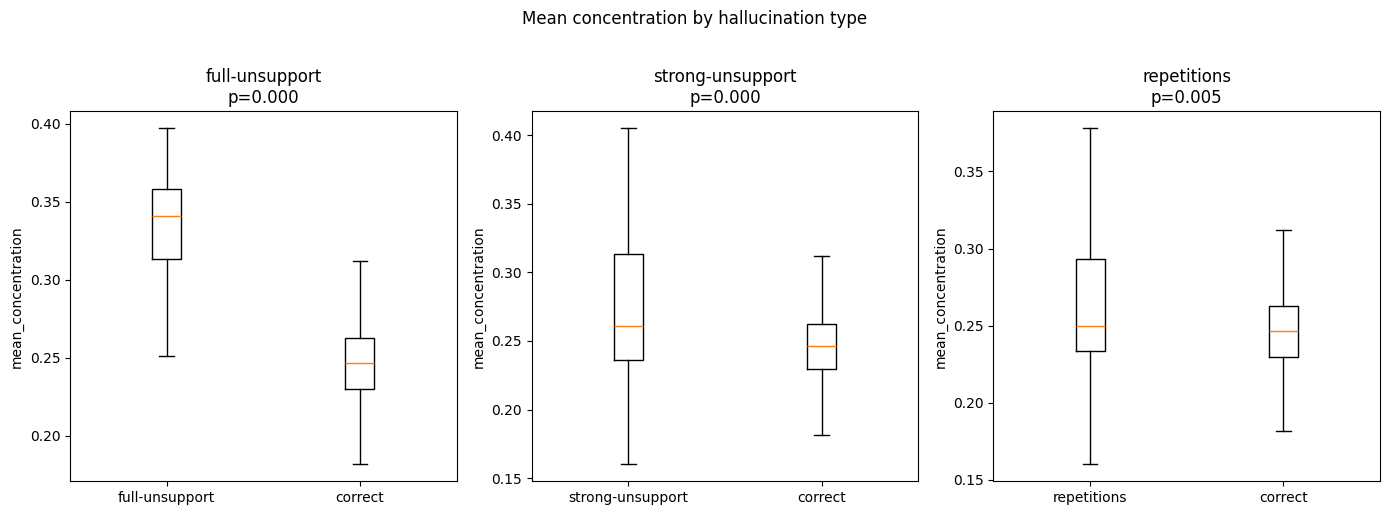

In [13]:
hallucination_types = ['full-unsupport', 'strong-unsupport', 'repetitions']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, htype in zip(axes, hallucination_types):
    pos = df[df[htype] == 1]['mean_concentration'].dropna()
    neg = df[(df[htype] == 0) & (~df['is_hallucination'])]['mean_concentration'].dropna()
    ax.boxplot([pos.values, neg.values], tick_labels=[htype, 'correct'], showfliers=False)
    _, p = mannwhitneyu(pos, neg, alternative='two-sided')
    ax.set_title(f"{htype}\np={p:.3f}")
    ax.set_ylabel("mean_concentration")
plt.suptitle("Mean concentration by hallucination type", y=1.02)
plt.tight_layout()
plt.show()

---
## Experiment 3 — Generation Dynamics
How do attention distributions evolve step by step during decoding?

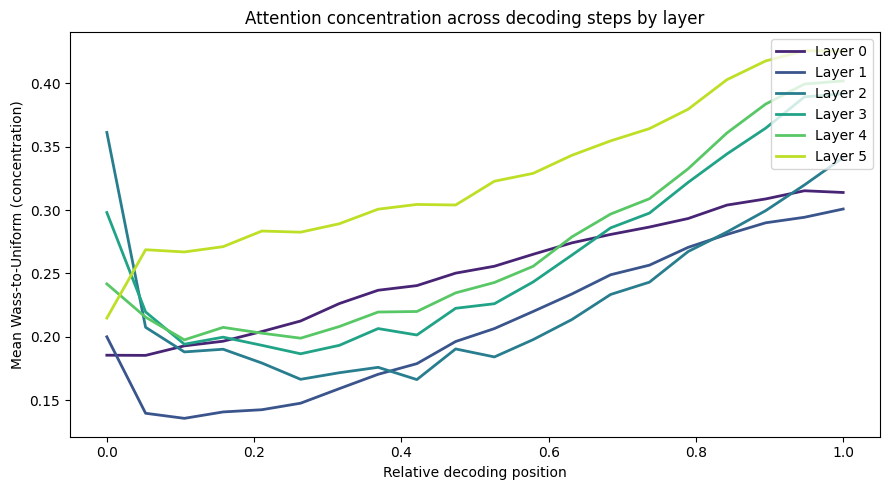

In [14]:
N_POINTS = 20
n_layers = 6

binned = np.full((n_layers, N_POINTS), np.nan)
counts = np.zeros((n_layers, N_POINTS))

for conc_mat in df['concentration_matrix']:
    if not isinstance(conc_mat, np.ndarray):
        continue
    T = conc_mat.shape[1]
    if T < 2:
        continue
    for t in range(T):
        bin_idx = min(int(t / T * N_POINTS), N_POINTS - 1)
        for l in range(n_layers):
            v = conc_mat[l, t]
            if not np.isnan(v):
                if np.isnan(binned[l, bin_idx]):
                    binned[l, bin_idx] = 0.0
                binned[l, bin_idx] += v
                counts[l, bin_idx] += 1

mean_trajectory = np.where(counts > 0, binned / counts, np.nan)
x = np.linspace(0, 1, N_POINTS)

fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, n_layers))
for l in range(n_layers):
    ax.plot(x, mean_trajectory[l], label=f"Layer {l}", color=colors[l], linewidth=2)
ax.set_xlabel("Relative decoding position")
ax.set_ylabel("Mean Wass-to-Uniform (concentration)")
ax.set_title("Attention concentration across decoding steps by layer")
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

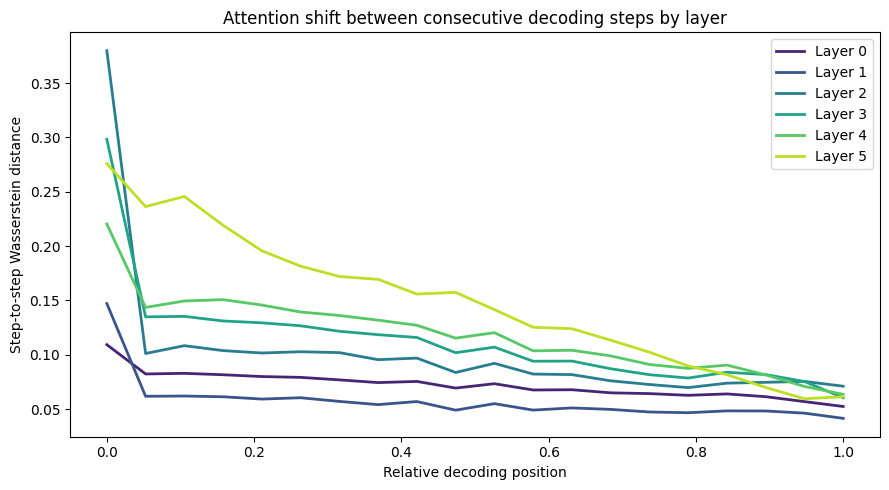

In [15]:
binned_step = np.full((n_layers, N_POINTS), np.nan)
counts_step = np.zeros((n_layers, N_POINTS))

for step_mat in df['step_ot_matrix']:
    if not isinstance(step_mat, np.ndarray) or step_mat.shape[1] == 0:
        continue
    T = step_mat.shape[1]
    for t in range(T):
        bin_idx = min(int(t / T * N_POINTS), N_POINTS - 1)
        for l in range(n_layers):
            v = step_mat[l, t]
            if not np.isnan(v):
                if np.isnan(binned_step[l, bin_idx]):
                    binned_step[l, bin_idx] = 0.0
                binned_step[l, bin_idx] += v
                counts_step[l, bin_idx] += 1

mean_step_traj = np.where(counts_step > 0, binned_step / counts_step, np.nan)

fig, ax = plt.subplots(figsize=(9, 5))
for l in range(n_layers):
    ax.plot(x, mean_step_traj[l], label=f"Layer {l}", color=colors[l], linewidth=2)
ax.set_xlabel("Relative decoding position")
ax.set_ylabel("Step-to-step Wasserstein distance")
ax.set_title("Attention shift between consecutive decoding steps by layer")
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

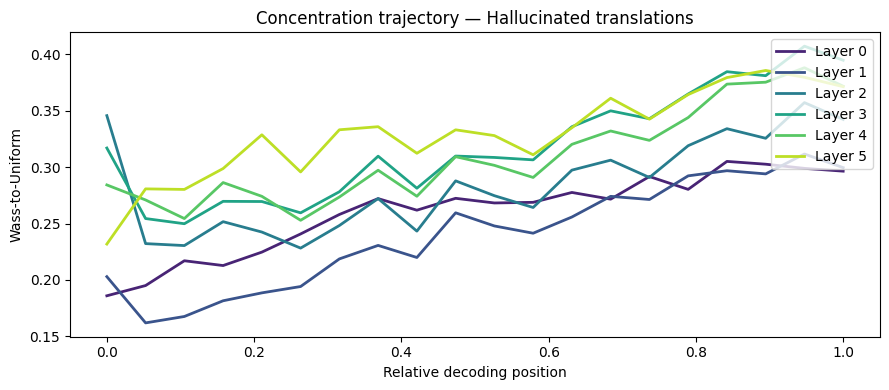

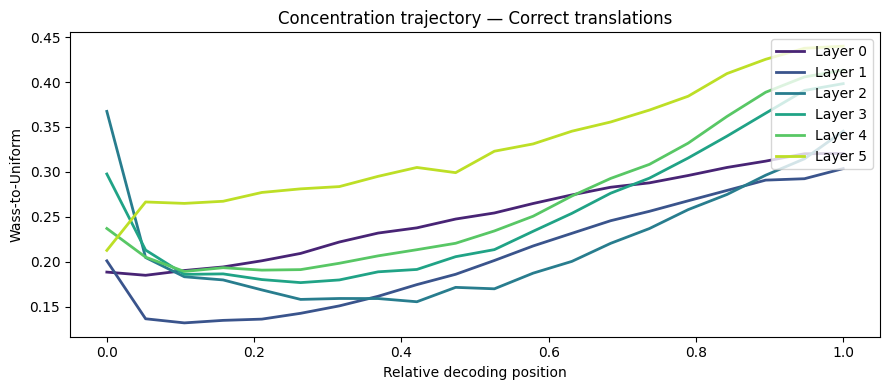

In [16]:
for group, label in [('hallucination', 'Hallucinated'), ('correct', 'Correct')]:
    sub = df[df['quality_group'] == group]
    binned_g = np.full((n_layers, N_POINTS), np.nan)
    counts_g  = np.zeros((n_layers, N_POINTS))
    for conc_mat in sub['concentration_matrix']:
        if not isinstance(conc_mat, np.ndarray):
            continue
        T = conc_mat.shape[1]
        if T < 2:
            continue
        for t in range(T):
            bin_idx = min(int(t / T * N_POINTS), N_POINTS - 1)
            for l in range(n_layers):
                v = conc_mat[l, t]
                if not np.isnan(v):
                    if np.isnan(binned_g[l, bin_idx]):
                        binned_g[l, bin_idx] = 0.0
                    binned_g[l, bin_idx] += v
                    counts_g[l, bin_idx] += 1
    traj = np.where(counts_g > 0, binned_g / counts_g, np.nan)

    fig, ax = plt.subplots(figsize=(9, 4))
    for l in range(n_layers):
        ax.plot(x, traj[l], label=f"Layer {l}", color=colors[l], linewidth=2)
    ax.set_title(f"Concentration trajectory — {label} translations")
    ax.set_xlabel("Relative decoding position")
    ax.set_ylabel("Wass-to-Uniform")
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

---
## Experiment 4 — Per-layer summary features & Spearman correlation
Rer-layer mean concentration and step OT,
correlated with the `full-unsupport` binary label.

In [17]:
def extract_per_layer_summary(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    sample = out['concentration_matrix'].dropna().iloc[0]
    num_layers = sample.shape[0]
    for l in range(num_layers):
        out[f'layer_{l}_mean_concentration'] = out['concentration_matrix'].apply(
            lambda x: float(np.nanmean(x[l])) if isinstance(x, np.ndarray) else np.nan
        )
        out[f'layer_{l}_mean_step_ot'] = out['step_ot_matrix'].apply(
            lambda x: float(np.nanmean(x[l])) if isinstance(x, np.ndarray) and x.shape[1] > 0 else np.nan
        )
    return out


def compute_label_correlations(df: pd.DataFrame, columns: list, label_col: str) -> pd.DataFrame:
    rows = []
    for col in columns:
        sub = df[[label_col, col]].dropna()
        if len(sub) < 3:
            rows.append({'column': col, 'n': len(sub), 'spearman_rho': np.nan, 'p_value': np.nan})
            continue
        rho, p = spearmanr(sub[label_col], sub[col])
        rows.append({'column': col, 'n': len(sub), 'spearman_rho': float(rho), 'p_value': float(p)})
    return pd.DataFrame(rows).sort_values('p_value')


df = extract_per_layer_summary(df)
num_layers = 6
per_layer_cols = [f'layer_{l}_mean_concentration' for l in range(num_layers)] + \
                 [f'layer_{l}_mean_step_ot'        for l in range(num_layers)]

corr_df = compute_label_correlations(df, per_layer_cols, 'full-unsupport')
print(corr_df.to_string(index=False))

                    column    n  spearman_rho  p_value
      layer_3_mean_step_ot 3414       -0.3023   0.0000
      layer_4_mean_step_ot 3414       -0.2954   0.0000
      layer_2_mean_step_ot 3414       -0.2952   0.0000
layer_2_mean_concentration 3414        0.2946   0.0000
layer_3_mean_concentration 3414        0.2905   0.0000
layer_4_mean_concentration 3414        0.2876   0.0000
layer_1_mean_concentration 3414        0.2851   0.0000
      layer_0_mean_step_ot 3414       -0.2591   0.0000
      layer_5_mean_step_ot 3414       -0.2501   0.0000
      layer_1_mean_step_ot 3414       -0.2466   0.0000
layer_5_mean_concentration 3414        0.1651   0.0000
layer_0_mean_concentration 3414        0.0552   0.0012


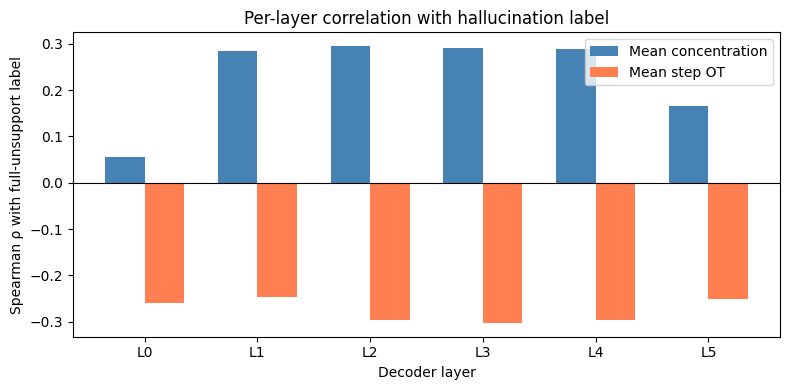

In [18]:
conc_rhos = [corr_df[corr_df['column'] == f'layer_{l}_mean_concentration']['spearman_rho'].values[0]
             for l in range(num_layers)]
step_rhos = [corr_df[corr_df['column'] == f'layer_{l}_mean_step_ot']['spearman_rho'].values[0]
             for l in range(num_layers)]

x_layers = np.arange(num_layers)
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x_layers - width/2, conc_rhos, width, label='Mean concentration', color='steelblue')
ax.bar(x_layers + width/2, step_rhos, width, label='Mean step OT',       color='coral')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x_layers)
ax.set_xticklabels([f'L{l}' for l in range(num_layers)])
ax.set_xlabel('Decoder layer')
ax.set_ylabel('Spearman ρ with full-unsupport label')
ax.set_title('Per-layer correlation with hallucination label')
ax.legend()
plt.tight_layout()
plt.show()

HALLUCINATED:
  src: Mal uni, mal mit Metall, mal mit Glas oder wieder in uni.
  mt:  Mal uni, mal mit Metall, mal mit Glas oder wieder in Uni.


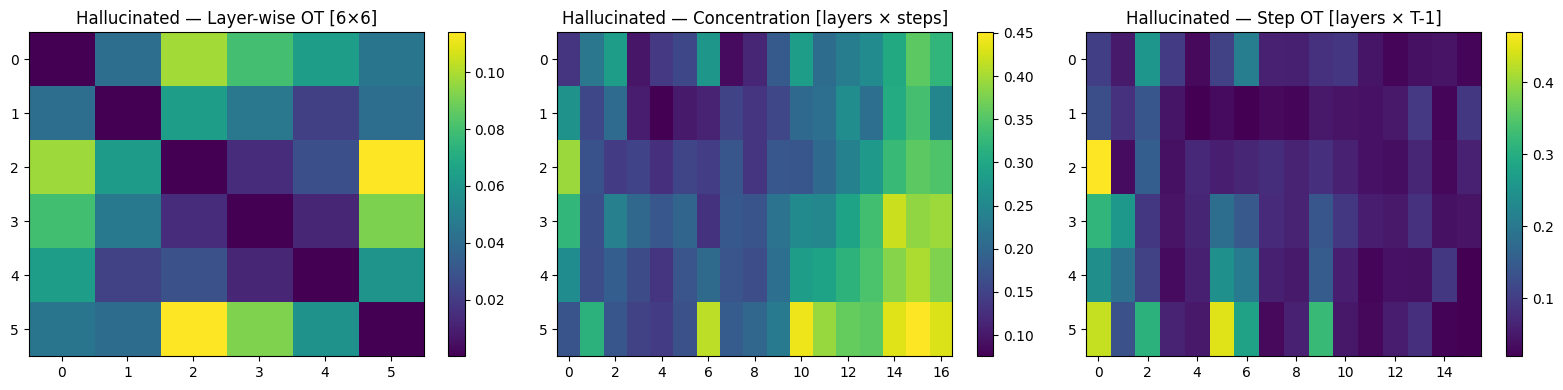

CORRECT:
  src: Nur Leib wir leben für andere ist werd.
  mt:  Only we live for others is who.


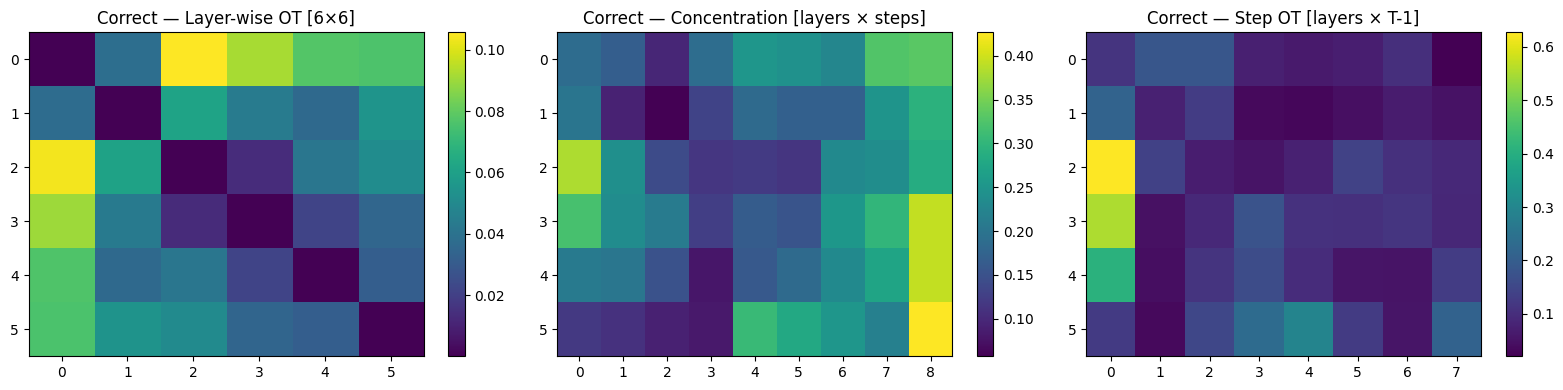

In [19]:
def show_heatmaps(row, title_prefix=""):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    for ax, key, title in zip(axes,
        ['layer_ot_matrix', 'concentration_matrix', 'step_ot_matrix'],
        ['Layer-wise OT [6×6]', 'Concentration [layers × steps]', 'Step OT [layers × T-1]']):
        mat = row[key]
        if not isinstance(mat, np.ndarray):
            continue
        im = ax.imshow(mat, aspect='auto', cmap='viridis')
        plt.colorbar(im, ax=ax)
        ax.set_title(f"{title_prefix}{title}")

    plt.tight_layout()
    plt.show()


hall_row    = df[df['full-unsupport'] == 1].iloc[0]
correct_row = df[(df['full-unsupport'] == 0) & (~df['is_hallucination'])].iloc[0]

print("HALLUCINATED:")
print(f"  src: {hall_row['src']}")
print(f"  mt:  {hall_row['mt']}")
show_heatmaps(hall_row, "Hallucinated — ")

print("CORRECT:")
print(f"  src: {correct_row['src']}")
print(f"  mt:  {correct_row['mt']}")
show_heatmaps(correct_row, "Correct — ")

---
## Experiment 5 — AUROC by Layer and Hallucination Type

Direct comparison to Table 2 of Guerreiro et al. (2023).
For each hallucination type and each layer we use mean concentration as the detector score
and compute AUROC — revealing which layer carries the strongest detection signal.

In [ ]:
from sklearn.metrics import roc_auc_score

def auroc_signed(labels, scores):
    """AUROC, flipped if below 0.5 so result is always >= 0.5."""
    a = roc_auc_score(labels, scores)
    return max(a, 1 - a)


hallucination_types = ['full-unsupport', 'strong-unsupport', 'repetitions']
num_layers = 6

auroc_rows = []
for htype in hallucination_types:
    labels = df[htype].fillna(0).astype(int).values
    if labels.sum() == 0:
        continue
    row = {'hallucination_type': htype}
    # Higher concentration -> more anomalous -> higher hallucination score.
    row['aggregate'] = roc_auc_score(labels, df['mean_concentration'].fillna(0).values)
    for l in range(num_layers):
        col = f'layer_{l}_mean_concentration'
        row[f'L{l}'] = roc_auc_score(labels, df[col].fillna(0).values)
    auroc_rows.append(row)

auroc_df = pd.DataFrame(auroc_rows).set_index('hallucination_type')
print("AUROC by hallucination type and layer (higher = better):")
print(auroc_df.round(3).to_string())


AUROC by hallucination type and layer (higher = better):
                    aggregate     L0     L1     L2     L3     L4     L5
hallucination_type                                                     
full-unsupport         0.9370 0.5840 0.9320 0.9460 0.9400 0.9350 0.7500
strong-unsupport       0.6290 0.5990 0.6580 0.6720 0.6520 0.5910 0.4610
repetitions            0.5680 0.6170 0.6000 0.6360 0.6670 0.5170 0.3740


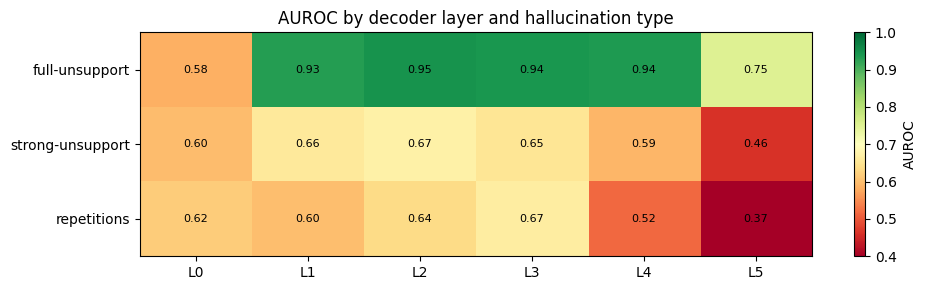

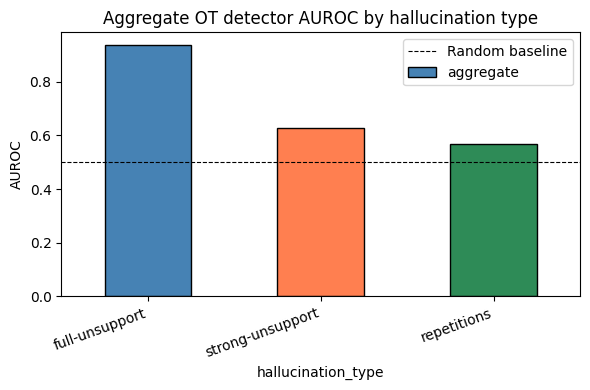

In [21]:
layer_cols = [f'L{l}' for l in range(num_layers)]
fig, ax = plt.subplots(figsize=(10, 3))
im = ax.imshow(auroc_df[layer_cols].values, aspect='auto', cmap='RdYlGn', vmin=0.4, vmax=1.0)
plt.colorbar(im, ax=ax, label='AUROC')
ax.set_xticks(range(num_layers))
ax.set_xticklabels(layer_cols)
ax.set_yticks(range(len(auroc_df)))
ax.set_yticklabels(auroc_df.index)
ax.set_title('AUROC by decoder layer and hallucination type')
for i in range(len(auroc_df)):
    for j in range(num_layers):
        val = auroc_df[layer_cols].values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
auroc_df['aggregate'].plot(kind='bar', ax=ax, color=['steelblue', 'coral', 'seagreen'], edgecolor='black')
ax.axhline(0.5, color='black', linestyle='--', linewidth=0.8, label='Random baseline')
ax.set_ylabel('AUROC')
ax.set_title('Aggregate OT detector AUROC by hallucination type')
ax.set_xticklabels(auroc_df.index, rotation=20, ha='right')
ax.legend()
plt.tight_layout()
plt.show()


---
## Experiment 6 — Routing Consistency

For each layer, routing entropy H(l) measures how spread the argmax attention position
is across generation steps. RC = -mean(H), so higher = more focused routing.

In [22]:
def routing_consistency(pi):
    pi = np.transpose(pi, (1, 0, 2))
    num_layers, T, S = pi.shape
    rc = np.zeros(num_layers)
    for l in range(num_layers):
        argmaxes = pi[l].argmax(axis=1)
        counts = np.bincount(argmaxes, minlength=S).astype(float)
        p_hat = counts / counts.sum()
        entropy = -np.sum(p_hat * np.log(np.clip(p_hat, 1e-12, None)))
        rc[l] = -entropy
    return rc

rc_list = []
for _, row in tqdm(df.iterrows(), total=len(df)):
    if isinstance(row['attn'], np.ndarray):
        rc_list.append(routing_consistency(row['attn']))
    else:
        rc_list.append(np.full(6, np.nan))

rc_array = np.stack(rc_list, axis=0)
rc_df = pd.DataFrame(rc_array, columns=[f'rc_L{l}' for l in range(6)])
for col in rc_df.columns:
    df[col] = rc_df[col].values

print("Routing consistency per layer (mean +/- std):")
print(rc_df.describe().loc[['mean', 'std']].round(4))


  0%|          | 0/3414 [00:00<?, ?it/s]

100%|██████████| 3414/3414 [00:00<00:00, 8117.72it/s]

Routing consistency per layer (mean +/- std):
       rc_L0   rc_L1   rc_L2   rc_L3   rc_L4   rc_L5
mean -0.4181 -0.5025 -1.7729 -1.4750 -1.3352 -0.8814
std   0.4217  0.5748  0.8889  0.8772  0.8621  0.5866


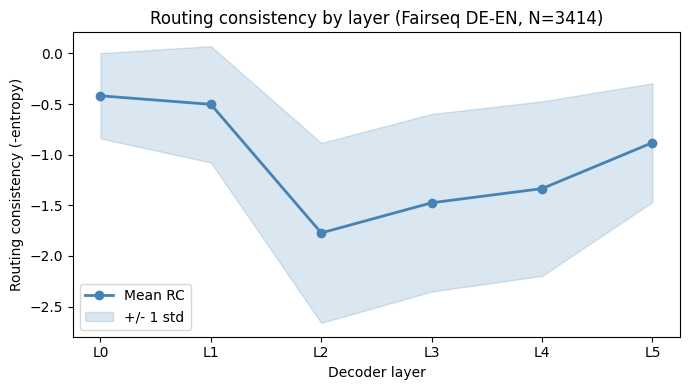

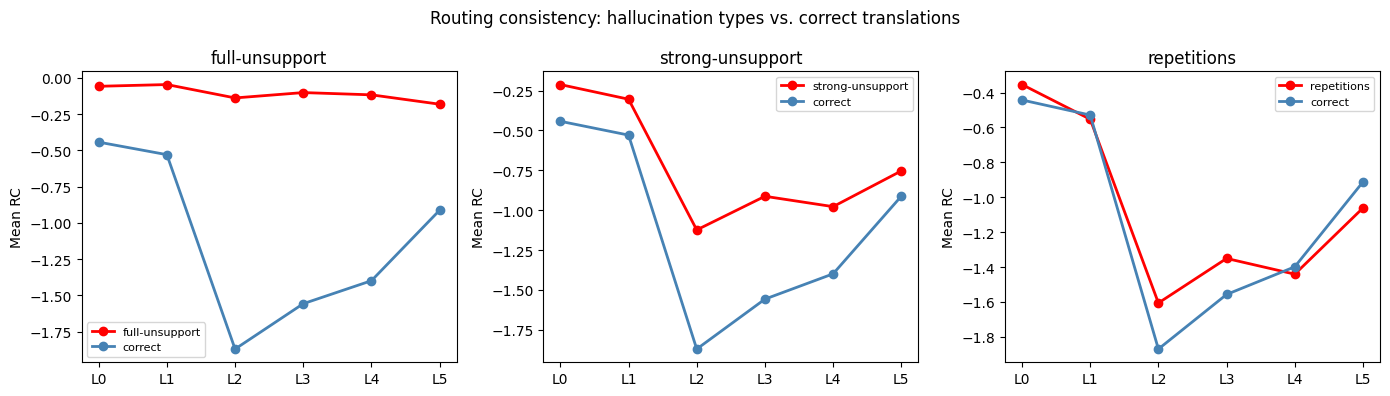

In [23]:
mean_rc = rc_df.mean()
std_rc  = rc_df.std()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(6), mean_rc.values, 'o-', color='steelblue', linewidth=2, label='Mean RC')
ax.fill_between(range(6),
                mean_rc.values - std_rc.values,
                mean_rc.values + std_rc.values,
                alpha=0.2, color='steelblue', label='+/- 1 std')
ax.set_xticks(range(6))
ax.set_xticklabels([f'L{l}' for l in range(6)])
ax.set_xlabel('Decoder layer')
ax.set_ylabel('Routing consistency (-entropy)')
ax.set_title('Routing consistency by layer (Fairseq DE-EN, N=3414)')
ax.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, htype in zip(axes, hallucination_types):
    pos_rc = rc_df[df[htype].fillna(0) == 1].mean()
    neg_rc = rc_df[(df[htype].fillna(0) == 0) & (~df['is_hallucination'])].mean()
    ax.plot(range(6), pos_rc.values, 'o-', color='red',       label=htype,    linewidth=2)
    ax.plot(range(6), neg_rc.values, 'o-', color='steelblue', label='correct', linewidth=2)
    ax.set_title(htype)
    ax.set_xticks(range(6))
    ax.set_xticklabels([f'L{l}' for l in range(6)])
    ax.set_ylabel('Mean RC')
    ax.legend(fontsize=8)
plt.suptitle('Routing consistency: hallucination types vs. correct translations')
plt.tight_layout()
plt.show()


In [ ]:
print("AUROC of routing consistency as hallucination detector:")
# RC = -entropy: hallucinated sentences have RC near 0 (uniform argmax = low entropy),
# correct sentences have more negative RC (diverse routing = high entropy).
# Higher (less negative) RC therefore predicts hallucination
rc_auroc_rows = []
for htype in hallucination_types:
    labels = df[htype].fillna(0).astype(int).values
    if labels.sum() == 0:
        continue
    row = {'hallucination_type': htype}
    agg_rc = rc_df.mean(axis=1).values
    row['aggregate'] = roc_auc_score(labels, agg_rc)
    for l in range(6):
        row[f'L{l}'] = roc_auc_score(labels, rc_df[f'rc_L{l}'].fillna(0).values)
    rc_auroc_rows.append(row)

rc_auroc_df = pd.DataFrame(rc_auroc_rows).set_index('hallucination_type')
print(rc_auroc_df.round(3).to_string())


AUROC of routing consistency as hallucination detector:
                    aggregate     L0     L1     L2     L3     L4     L5
hallucination_type                                                     
full-unsupport         0.9570 0.7890 0.7850 0.9550 0.9450 0.9280 0.8810
strong-unsupport       0.6720 0.6530 0.6200 0.6940 0.6890 0.6260 0.5720
repetitions            0.5080 0.5360 0.4850 0.5400 0.5410 0.4680 0.4140


---
## Experiment 7 — Wass-to-Data

The OT paper's strongest individual detector. We compare each test sentence's
step-averaged attention at each layer to a reference set of good translations.
Bottom-k averaging with k=4 and length window delta=0.1, same as the paper.

This reveals which layer's Wass-to-Data is the strongest detector,
extending the paper's aggregate result to a layer-resolved analysis.

In [ ]:
hallucination_label_cols = ['full-unsupport', 'strong-unsupport', 'repetitions',
                             'named-entities', 'omission']
available_label_cols = [c for c in hallucination_label_cols if c in df.columns]

ref_mask = (df[available_label_cols].fillna(0) == 0).all(axis=1)
ref_df_wt = df[ref_mask].reset_index(drop=True)

print(f"Reference set: {ref_mask.sum()} confirmed-correct sentences "
      f"({ref_mask.mean()*100:.1f}% of corpus)")

ref_attns = [r for r in ref_df_wt['attn'].values if isinstance(r, np.ndarray)]
ref_lens  = [int(r.shape[0]) for r in ref_attns]

DELTA   = 0.1
K       = 4
MAX_REF = 1000


Reference set: 2882 confirmed-correct sentences (84.4% of corpus)


In [26]:
def wass_to_data_layer_fast(test_attn, ref_attns, test_len, ref_lens,
                             layer, delta=DELTA, k=K, max_ref=MAX_REF):
    """Wass-to-Data score for one layer.

    Compares the step-averaged attention at `layer` for the test sentence
    against length-matched references using exact W1 (w1_exact_1d).
    Returns the mean of the bottom-k distances (most similar references).
    """
    pi_test = test_attn[:, layer, :].mean(axis=0)
    pi_test = pi_test / (pi_test.sum() + 1e-9)
    lo, hi = test_len * (1 - delta), test_len * (1 + delta)

    filtered_refs = [ref_attns[i][:, layer, :].mean(axis=0)
                     for i in range(min(len(ref_attns), max_ref))
                     if lo <= ref_lens[i] <= hi]
    if not filtered_refs:
        return np.nan

    n = max(len(pi_test), max(len(r) for r in filtered_refs))
    pi_test_pad = np.pad(pi_test, (0, n - len(pi_test)))
    pi_test_pad /= pi_test_pad.sum() + 1e-9

    ref_matrix = np.stack([
        np.pad(r / (r.sum() + 1e-9), (0, n - len(r)))
        for r in filtered_refs
    ])

    cdf_test = np.cumsum(pi_test_pad)
    cdf_refs = np.cumsum(ref_matrix, axis=1)
    distances = np.sum(np.abs(cdf_refs - cdf_test), axis=1) / max(n - 1, 1)

    distances.sort()
    return float(np.mean(distances[:k]))


In [27]:
wtd_scores = np.full((len(df), num_layers), np.nan)

for i, (_, row) in enumerate(tqdm(df.iterrows(), total=len(df))):
    if not isinstance(row['attn'], np.ndarray):
        continue
    test_len = int(row['attn'].shape[0])
    for l in range(num_layers):
        wtd_scores[i, l] = wass_to_data_layer_fast(
            row['attn'], ref_attns, test_len, ref_lens, layer=l
        )

for l in range(num_layers):
    df[f'wtd_L{l}'] = wtd_scores[:, l]
df['wtd_aggregate'] = np.nanmean(wtd_scores, axis=1)
print("Done.")

100%|██████████| 3414/3414 [00:48<00:00, 70.30it/s]

Done.



C:\Users\Admin\AppData\Local\Temp\ipykernel_71020\721885012.py:14: RuntimeWarning: Mean of empty slice
  df['wtd_aggregate'] = np.nanmean(wtd_scores, axis=1)


Aggregate WTD vs WTU:
                    WTD_agg  WTU_agg
hallucination_type                  
full-unsupport       0.8010   0.9370
strong-unsupport     0.7700   0.6290
repetitions          0.7900   0.5680


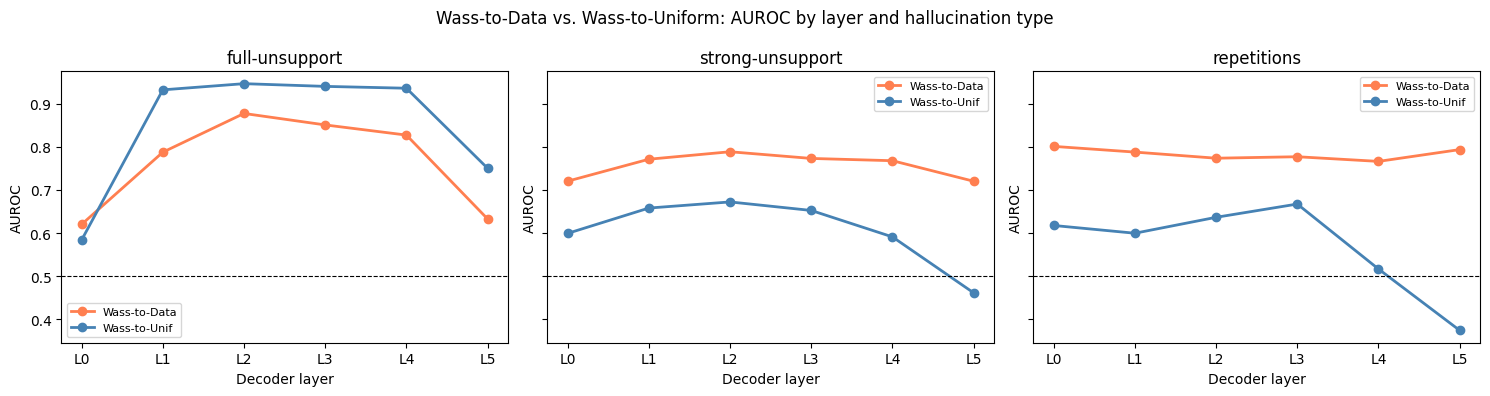

In [ ]:
wtd_auroc_rows = []
for htype in hallucination_types:
    labels = df[htype].fillna(0).astype(int).values
    if labels.sum() == 0:
        continue
    row = {'hallucination_type': htype}

    valid_mask = df['wtd_aggregate'].notna().values
    row['WTD_agg'] = auroc_signed(labels[valid_mask], df['wtd_aggregate'].values[valid_mask])
    row['WTU_agg'] = roc_auc_score(labels, df['mean_concentration'].fillna(0).values)

    for l in range(num_layers):
        vm_l = df[f'wtd_L{l}'].notna().values
        row[f'WTD_L{l}'] = auroc_signed(labels[vm_l], df[f'wtd_L{l}'].values[vm_l])
        row[f'WTU_L{l}'] = roc_auc_score(labels, df[f'layer_{l}_mean_concentration'].fillna(0).values)
    wtd_auroc_rows.append(row)

wtd_auroc_df = pd.DataFrame(wtd_auroc_rows).set_index('hallucination_type')

print("Aggregate WTD vs WTU:")
print(wtd_auroc_df[['WTD_agg', 'WTU_agg']].round(3))

fig, axes = plt.subplots(1, len(hallucination_types), figsize=(15, 4), sharey=True)
for ax, htype in zip(axes, hallucination_types):
    row = wtd_auroc_df.loc[htype]
    wtd = [row[f'WTD_L{l}'] for l in range(num_layers)]
    wtu = [row[f'WTU_L{l}'] for l in range(num_layers)]
    ax.plot(range(num_layers), wtd, 'o-', color='coral',     label='Wass-to-Data', linewidth=2)
    ax.plot(range(num_layers), wtu, 'o-', color='steelblue', label='Wass-to-Unif', linewidth=2)
    ax.axhline(0.5, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(htype)
    ax.set_xticks(range(num_layers))
    ax.set_xticklabels([f'L{l}' for l in range(num_layers)])
    ax.set_xlabel('Decoder layer')
    ax.set_ylabel('AUROC')
    ax.legend(fontsize=8)
plt.suptitle('Wass-to-Data vs. Wass-to-Uniform: AUROC by layer and hallucination type')
plt.tight_layout()
plt.show()
